# Label Data
This notebook is made to label the data. To create correct labels for each of the testing experimental data examples in order to ensure the corectness of the runs.

In [51]:
import numpy as np
import pandas as pd

import sys
import os
sys.path.append(os.path.abspath('..'))

from script.helper_methods.data_loader import load_raw_data
from script.helper_methods import data_preprocessing as dp
from script.helper_methods import data_visualization as dv


In [52]:
def save_labeled_data(df, name):
    BASE_PATH = os.path.abspath(os.path.join(os.getcwd(), '..'))
    LABELED_PATH = os.path.join(BASE_PATH, 'data', 'labeled')
    if not os.path.exists(LABELED_PATH):
        os.makedirs(LABELED_PATH)
    output_path = os.path.join(LABELED_PATH, f'labeled_{name}.csv')
    df.to_csv(output_path, index=True)
    print(f"Labeled data saved to {output_path}")

In [53]:
def set_default_plug(df):
    dp.create_target_column(df) # Makes plug = 1/0 column, based on flow/pressure threshold
    dp.create_future_target(df)

In [54]:
def set_no_plug(df):
    df['Plug'] = 0
    df['Plug_future'] = 0

In [55]:
def show_info(df):
    print(f"Dataset columns: {df.columns.tolist()}")
    print(f"Duplicate rows: {df.duplicated().sum()}")
    
    df.index = pd.to_datetime(df.index)
    print("Duplicate index timestamps:", df.index.duplicated().sum())
    
    return df.head()

In [56]:
def set_plug_at_time(df, time_start, time_end):
    # find first plug
    start_time = f'1900-01-01 {time_start}.330000'
    end_time = f'1900-01-01 {time_end}.330000'

    # set plug column
    if 'Plug' not in df.columns:
        df['Plug'] = 0  
    df['Plug'] = np.where((df.index >= start_time) & (df.index <= end_time), 1, df['Plug'])
    
    dp.create_future_target(df)

In [57]:
def add_logId_column(df, log_id):
    '''Add a LogId column to the dataframe to specify which log the data comes from'''
    df = df.copy()
    df['LogId'] = log_id
    return df

In [58]:
def cut(df, seconds_elapsed_start, seconds_elapsed_stop):
    start = df.index[0] + pd.Timedelta(seconds=seconds_elapsed_start)
    stop = df.index[0] + pd.Timedelta(seconds=seconds_elapsed_stop)
    
    return df[(df.index < start) | (df.index > stop)]

In [59]:
# Load the data
print("Loading datasets...")
dataset1 = load_raw_data()
dataset2 = load_raw_data(path="../data/raw_data/data2/*.csv")
dataset3 = load_raw_data(path="../data/raw_data/data3/*.csv")
dataset4 = load_raw_data(path="../data/raw_data/data4/*.csv")
dataset5 = load_raw_data(path="../data/raw_data/data5/*.csv")
dataset6 = load_raw_data(path="../data/raw_data/data6/*.csv")
dataset7 = load_raw_data(path="../data/raw_data/data7/*.csv")
dataset8 = load_raw_data(path="../data/raw_data/data8/*.csv")
dataset9 = load_raw_data(path="../data/raw_data/data9/*.csv")
dataset10 = load_raw_data(path="../data/raw_data/data10/*.csv")
dataset11 = load_raw_data(path="../data/raw_data/data11/*.csv")
dataset12 = load_raw_data(path="../data/raw_data/data12/*.csv")
print("Datasets loaded.")

Loading datasets...
Datasets loaded.


In [60]:
dataset1.head(5)

,Flow rate (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Temperature TS outlet (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean)
Time,,,,,,,,
1900-01-01 09:13:23.564,2006.990755,0.663001,1.006496,1.122522,-6.231957,-6.344172,-6.309016,25.589479
1900-01-01 09:13:23.614,2006.802163,0.666047,1.010171,1.129320,-6.287087,-6.373047,-6.327391,25.573727
1900-01-01 09:13:23.664,2006.990755,0.666782,1.016682,1.137956,-6.245083,-6.338922,-6.322141,25.592105
1900-01-01 09:13:23.714,2005.764905,0.662791,1.010171,1.127850,-6.255584,-6.370422,-6.324766,25.584228
1900-01-01 09:13:23.764,2005.576313,0.663421,1.014057,1.130607,-6.247708,-6.375672,-6.322141,25.589479


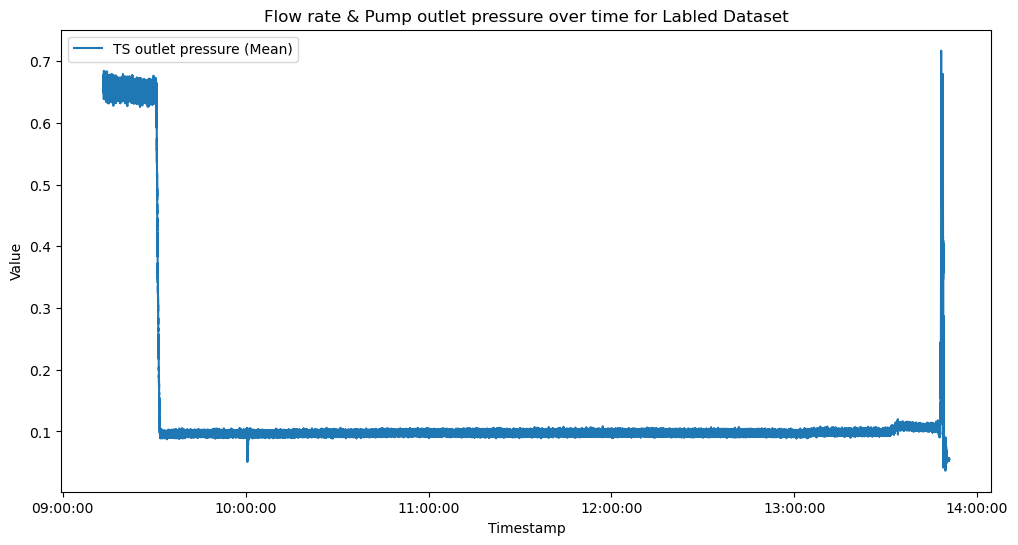

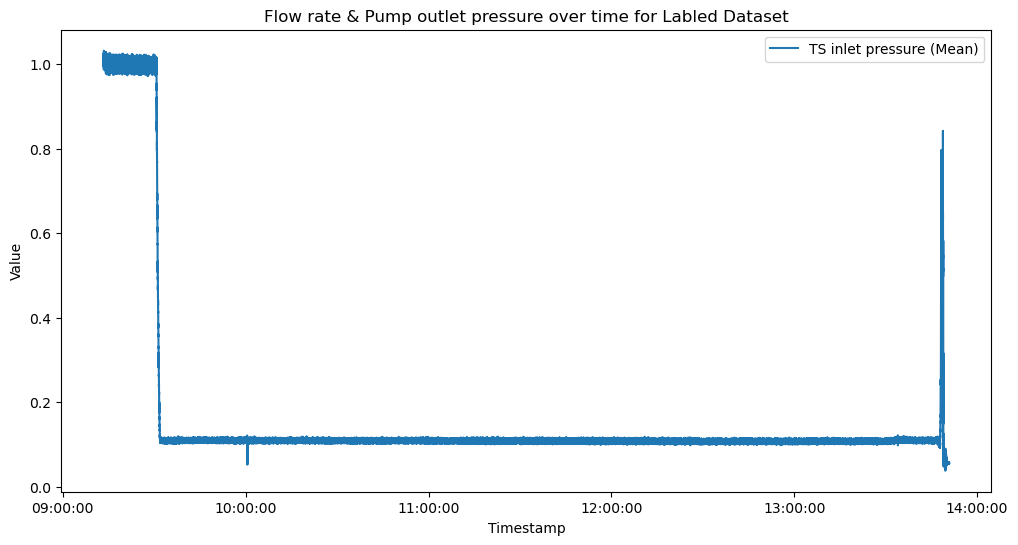

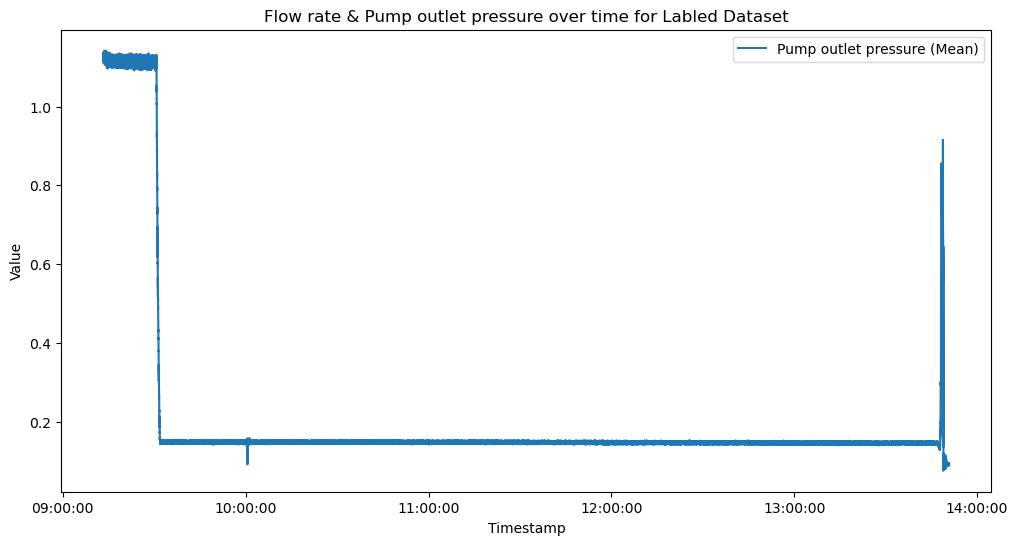

In [61]:
dv.visualize_flow_rate(dataset1, key="TS outlet pressure (Mean)", name="Labled Dataset")
dv.visualize_flow_rate(dataset1, key="TS inlet pressure (Mean)", name="Labled Dataset")
dv.visualize_flow_rate(dataset1, key="Pump outlet pressure (Mean)", name="Labled Dataset")

## For each dataset look at it and label it

⚙️ Flow threshold set to: 327.32


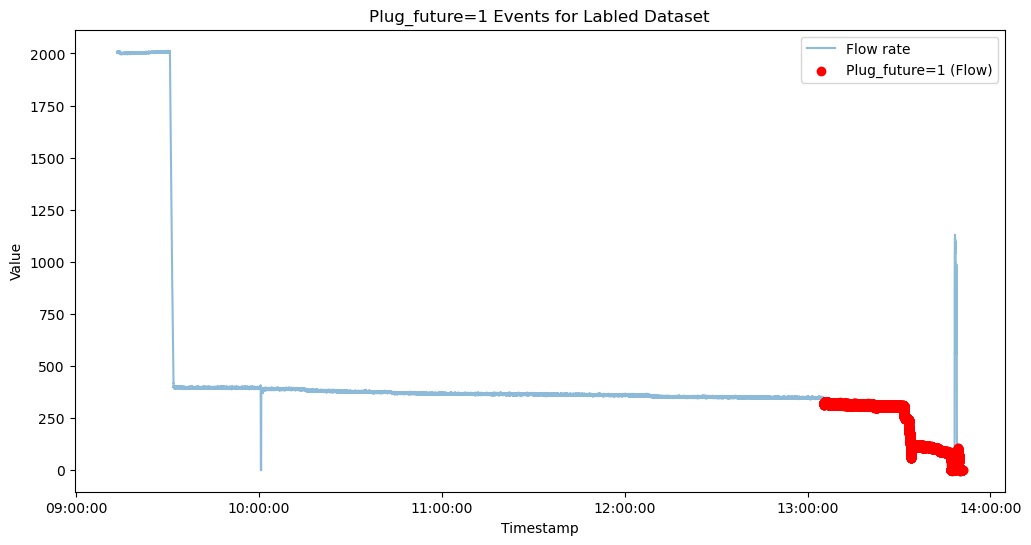

In [62]:
set_default_plug(dataset1)
dataset1 = add_logId_column(dataset1, 1)
dv.visualize_plug_event(dataset1, anomalies=True, plug_column="Plug_future", name="Labled Dataset")

# Dataset 2

⚙️ Flow threshold set to: 346.84


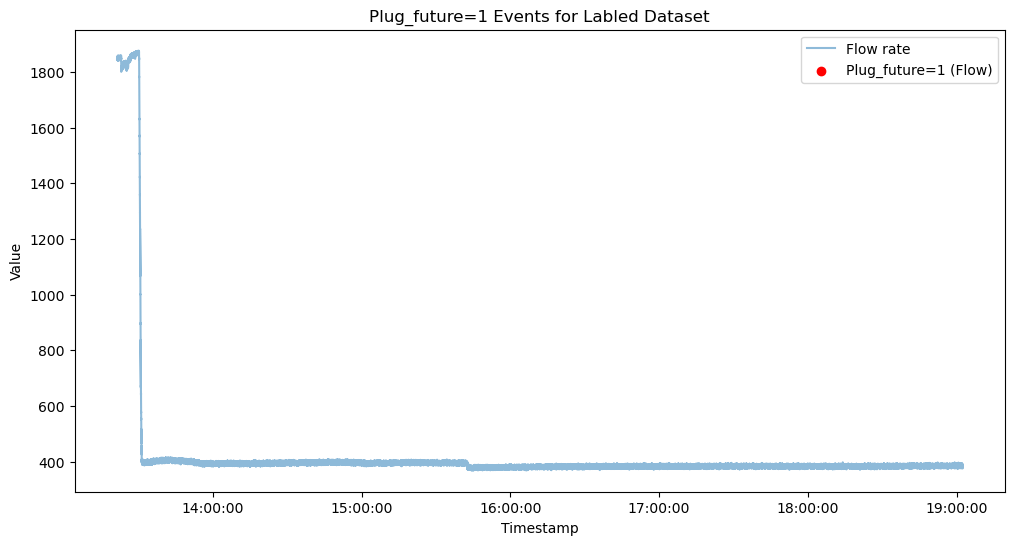

In [63]:
set_default_plug(dataset2)
dataset2 = add_logId_column(dataset2, 2)
dv.visualize_plug_event(dataset2, anomalies=True, plug_column="Plug_future", name="Labled Dataset")

# Dataset 3

In [64]:
show_info(dataset3)

Dataset columns: ['TS outlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Differential pressure (Mean)', 'Flow rate (Mean)', 'Tank temperature (Mean)', 'Temperature TS inlet (Mean)', 'Temperature TS outlet (Mean)', 'Bypass temperature (Mean)', 'Temperature TS outlet (Std Dev)', 'Temperature TS inlet (Std Dev)', 'Bypass temperature (Std Dev)', 'Tank temperature (Std Dev)', 'Differential pressure (Std Dev)', 'Pressure before pump (Std Dev)', 'Pressure after pump (Std Dev)', 'Flow rate (Std Dev)']
Duplicate rows: 0
Duplicate index timestamps: 0


,TS outlet pressure (Mean),Pump outlet pressure (Mean),Differential pressure (Mean),Flow rate (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Temperature TS outlet (Mean),Bypass temperature (Mean),Temperature TS outlet (Std Dev),Temperature TS inlet (Std Dev),Bypass temperature (Std Dev),Tank temperature (Std Dev),Differential pressure (Std Dev),Pressure before pump (Std Dev),Pressure after pump (Std Dev),Flow rate (Std Dev)
Time,,,,,,,,,,,,,,,,
1900-01-01 10:08:28.347,0.759556,0.000932,0.212329,1561.091208,7.280965,-2.381982,-0.025701,21.950240,0.241412,0.649763,0.230938,1.075645,0.017048,0.083666,0.005487,11.664282
1900-01-01 10:08:28.846,0.760145,0.000721,0.213470,1560.987274,7.231516,-2.370934,-0.125659,21.969181,0.269339,0.664583,0.236032,1.083438,0.016058,0.090984,0.005661,12.519271
1900-01-01 10:08:29.350,0.758179,0.000997,0.213269,1562.163933,7.182435,-2.299218,-0.214808,21.954802,0.257213,0.630675,0.242421,1.112259,0.016666,0.095589,0.005747,11.097039
1900-01-01 10:08:29.848,0.760242,0.000642,0.212117,1563.040239,7.017590,-2.263474,-0.313047,21.937244,0.279101,0.723726,0.245817,1.062527,0.016441,0.111216,0.005620,11.240369
1900-01-01 10:08:30.347,0.759019,0.000795,0.212366,1561.894331,7.095533,-2.231526,-0.370821,21.960763,0.266585,0.612376,0.251867,1.087259,0.016192,0.112690,0.005541,11.301572


In [65]:
# cut the first 3200s from dataset3
dataset3 = dataset3.iloc[3200:]
set_no_plug(dataset3)
dataset3 = add_logId_column(dataset3, 3)

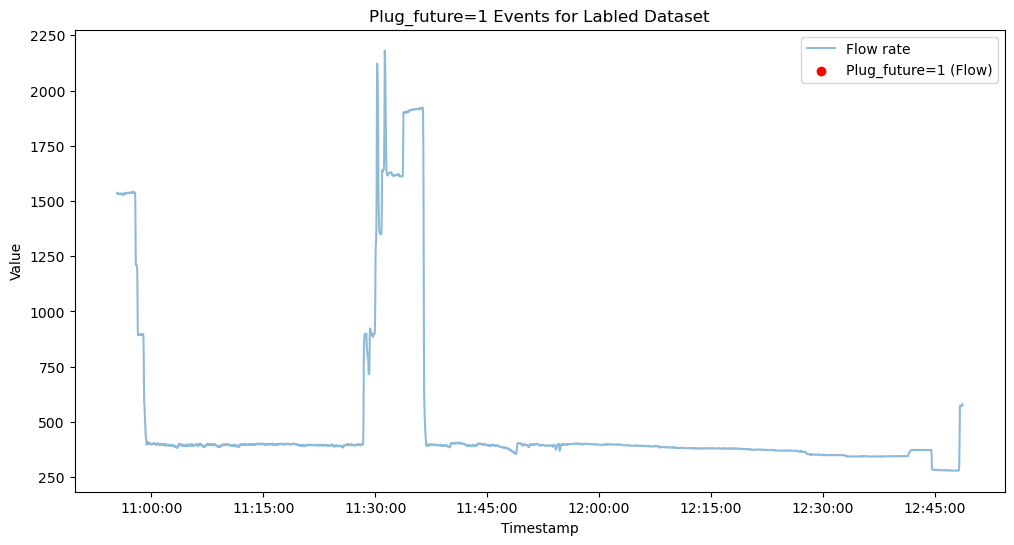

In [66]:
dv.visualize_plug_event(dataset3, anomalies=True, plug_column="Plug_future", name="Labled Dataset")

# Data 4
No blockage

In [67]:
show_info(dataset4)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']
Duplicate rows: 0
Duplicate index timestamps: 0


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
1900-01-01 15:14:08.717,21.289102,-7.686529,21.978412,-7.887004,0.234429,0.241925,0.430600,1.023696
1900-01-01 15:14:09.717,21.273088,-7.692305,21.964366,-7.885036,0.233763,0.241222,0.430003,1.000122
1900-01-01 15:14:10.717,21.281620,-7.690073,21.969485,-7.881623,0.233689,0.240896,0.431041,0.957688
1900-01-01 15:14:11.717,21.273613,-7.691123,21.965547,-7.872829,0.234797,0.243133,0.432006,0.849248
1900-01-01 15:14:12.717,21.278076,-7.700311,21.966991,-7.865742,0.234015,0.241999,0.430940,0.594648


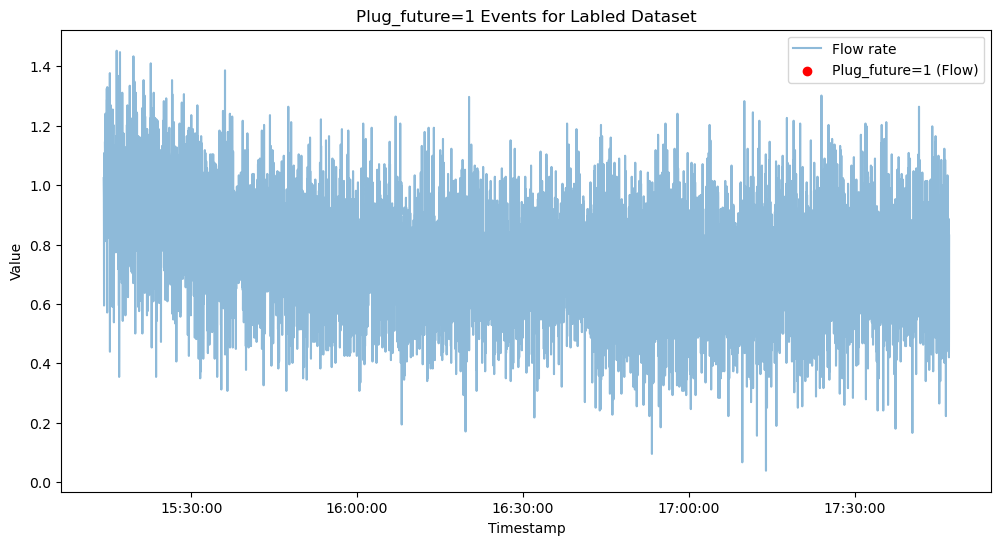

In [68]:
set_no_plug(dataset4)
dataset4 = add_logId_column(dataset4, 4)
dv.visualize_plug_event(dataset4, anomalies=True, plug_column="Plug_future", name="Labled Dataset")

In [69]:
# check for big values
print("Max values in dataset4:\n", dataset4.max())
print("Min values in dataset4:\n", dataset4.min())
print(dataset4.info())

Max values in dataset4:
 Temperature TS outlet (Mean)    21.544143
Temperature TS inlet (Mean)      0.457931
Bypass temperature (Mean)       25.229397
Tank temperature (Mean)         -1.477327
TS outlet pressure (Mean)        0.581027
TS inlet pressure (Mean)         0.638479
Pump outlet pressure (Mean)      1.202929
Flow rate (Mean)                 1.452743
Plug                             0.000000
Plug_future                      0.000000
LogId                            4.000000
dtype: float64
Min values in dataset4:
 Temperature TS outlet (Mean)    20.875760
Temperature TS inlet (Mean)     -7.704643
Bypass temperature (Mean)       21.725973
Tank temperature (Mean)         -7.887004
TS outlet pressure (Mean)        0.066717
TS inlet pressure (Mean)         0.066913
Pump outlet pressure (Mean)      0.124967
Flow rate (Mean)                 0.038301
Plug                             0.000000
Plug_future                      0.000000
LogId                            4.000000
dtype: floa

In [70]:
def contains_infinite_or_big_values(df, threshold=1e6):
    '''Check if DataFrame contains infinite or very large values'''
    if np.isinf(df.select_dtypes(include=['number'])).values.any():
        return True
    if (df.select_dtypes(include=['number']).abs() > threshold).values.any():
        return True
    return False


In [71]:
dataset4.describe(include='all')

,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean),Plug,Plug_future,LogId
count,9178.000000,9178.000000,9178.000000,9178.000000,9178.000000,9178.000000,9178.000000,9178.000000,9178.0,9178.0,9178.0
mean,21.380588,-1.849395,23.187966,-2.562591,0.179489,0.200539,0.340269,0.756685,0.0,0.0,4.0
std,0.091052,1.374509,0.379009,1.013022,0.104925,0.116925,0.203421,0.183523,0.0,0.0,0.0
min,20.875760,-7.704643,21.725973,-7.887004,0.066717,0.066913,0.124967,0.038301,0.0,0.0,4.0
25%,21.354372,-2.289451,23.118292,-2.638094,0.074225,0.073901,0.132944,0.632367,0.0,0.0,4.0
50%,21.398837,-1.970142,23.198467,-2.491095,0.216226,0.250576,0.414133,0.754952,0.0,0.0,4.0
75%,21.432965,-0.846343,23.294034,-2.020994,0.217219,0.273315,0.415754,0.877537,0.0,0.0,4.0
max,21.544143,0.457931,25.229397,-1.477327,0.581027,0.638479,1.202929,1.452743,0.0,0.0,4.0


In [72]:
contains_infinite_or_big_values(dataset4)

False

# Dataset 5
Plug at 70 mins

In [73]:
show_info(dataset5)

Dataset columns: ['TS outlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Differential pressure (Mean)', 'Flow rate (Mean)', 'Tank temperature (Mean)', 'Temperature TS inlet (Mean)', 'Temperature TS outlet (Mean)', 'Bypass temperature (Mean)', 'Temperature TS outlet (Std Dev)', 'Temperature TS inlet (Std Dev)', 'Bypass temperature (Std Dev)', 'Tank temperature (Std Dev)', 'Differential pressure (Std Dev)', 'Pressure before pump (Std Dev)', 'Pressure after pump (Std Dev)', 'Flow rate (Std Dev)']
Duplicate rows: 0
Duplicate index timestamps: 0


,TS outlet pressure (Mean),Pump outlet pressure (Mean),Differential pressure (Mean),Flow rate (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Temperature TS outlet (Mean),Bypass temperature (Mean),Temperature TS outlet (Std Dev),Temperature TS inlet (Std Dev),Bypass temperature (Std Dev),Tank temperature (Std Dev),Differential pressure (Std Dev),Pressure before pump (Std Dev),Pressure after pump (Std Dev),Flow rate (Std Dev)
Time,,,,,,,,,,,,,,,,
1900-01-01 11:07:40.450,0.652198,0.002561,0.216821,1197.850879,21.892479,-6.356868,-5.944637,-5.825225,0.244302,0.724920,0.213840,0.282836,0.018072,0.081870,0.004608,11.816486
1900-01-01 11:07:40.949,0.650550,0.002615,0.216269,1196.577000,21.904315,-6.356699,-5.943776,-5.804735,0.247066,0.757112,0.213078,0.283316,0.018405,0.080948,0.004419,11.061990
1900-01-01 11:07:41.453,0.651297,0.002800,0.215000,1192.332124,21.883107,-6.318099,-5.939004,-5.823056,0.254509,0.747501,0.219824,0.281944,0.018836,0.079520,0.004669,11.592692
1900-01-01 11:07:41.949,0.651998,0.002484,0.215635,1189.644134,21.905444,-6.318045,-5.936312,-5.803727,0.245705,0.761614,0.199970,0.279040,0.018200,0.080179,0.005180,11.194329
1900-01-01 11:07:42.453,0.656662,0.002737,0.219138,1189.778269,21.904721,-6.317839,-5.936660,-5.802740,0.244332,0.777832,0.206917,0.256907,0.018160,0.082592,0.004637,10.450238


In [74]:
# Find 70 minutes marker
start_time = dataset5.index.min()
marker_time = start_time + pd.Timedelta(minutes=70)
print(f"70 minutes marker timestamp: {marker_time}")

dataset5 = add_logId_column(dataset5, 5)

# set plug
dataset5['Plug'] = np.where(dataset5.index >= marker_time, 1, 0)
dp.create_future_target(dataset5)

70 minutes marker timestamp: 1900-01-01 12:17:40.450000


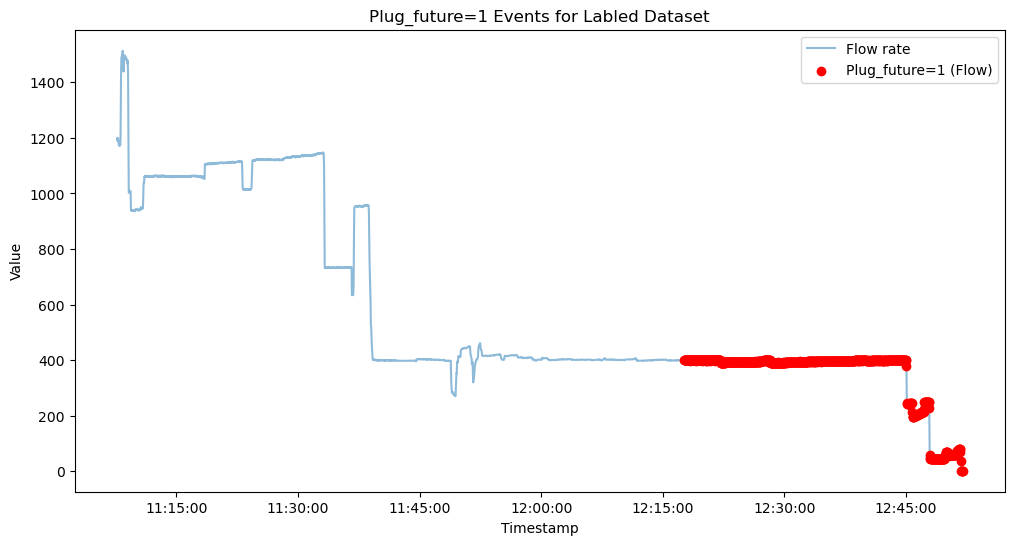

In [75]:
dv.visualize_plug_event(dataset5, anomalies=True, plug_column="Plug_future", name="Labled Dataset")

# Dataset 6
No plug - manual adjustments

In [76]:
show_info(dataset6)

Dataset columns: ['TS outlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Differential pressure (Mean)', 'Flow rate (Mean)', 'Tank temperature (Mean)', 'Temperature TS inlet (Mean)', 'Temperature TS outlet (Mean)', 'Bypass temperature (Mean)', 'Temperature TS outlet (Std Dev)', 'Temperature TS inlet (Std Dev)', 'Bypass temperature (Std Dev)', 'Tank temperature (Std Dev)', 'Differential pressure (Std Dev)', 'Pressure before pump (Std Dev)', 'Pressure after pump (Std Dev)', 'Flow rate (Std Dev)']
Duplicate rows: 0
Duplicate index timestamps: 0


,TS outlet pressure (Mean),Pump outlet pressure (Mean),Differential pressure (Mean),Flow rate (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Temperature TS outlet (Mean),Bypass temperature (Mean),Temperature TS outlet (Std Dev),Temperature TS inlet (Std Dev),Bypass temperature (Std Dev),Tank temperature (Std Dev),Differential pressure (Std Dev),Pressure before pump (Std Dev),Pressure after pump (Std Dev),Flow rate (Std Dev)
Time,,,,,,,,,,,,,,,,
1900-01-01 11:44:15.469,-0.000953,0.000388,-0.002267,0.751986,22.254471,23.476945,22.523866,23.597269,0.204264,0.149411,0.118877,0.198649,0.013532,0.004897,0.005212,3.493279
1900-01-01 11:44:15.973,-0.000864,0.000299,-0.002195,0.701742,22.275812,23.469334,22.524412,23.596239,0.177941,0.149632,0.125484,0.187145,0.013116,0.005382,0.005186,3.441039
1900-01-01 11:44:16.474,-0.000679,0.000365,-0.002517,0.576880,22.277582,23.477137,22.522801,23.594067,0.177954,0.144385,0.118495,0.207919,0.012904,0.005223,0.005290,3.247005
1900-01-01 11:44:16.970,-0.000762,0.000494,-0.002137,0.809020,22.254735,23.465830,22.521484,23.593299,0.201474,0.144347,0.118798,0.196353,0.014150,0.005094,0.005319,2.960882
1900-01-01 11:44:17.469,-0.000832,0.000511,-0.002550,0.612487,22.248877,23.471958,22.525223,23.593919,0.214081,0.154330,0.122937,0.168015,0.014046,0.004871,0.005322,3.166494


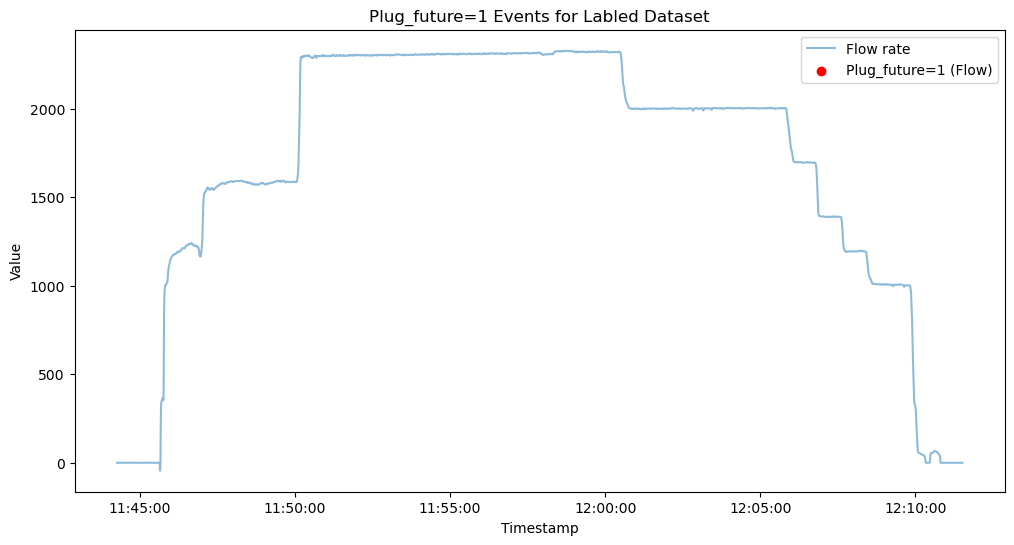

In [77]:
set_no_plug(dataset6)
dataset6 = add_logId_column(dataset6, 6)
dv.visualize_plug_event(dataset6, anomalies=True, plug_column="Plug_future", name="Labled Dataset")

# Dataset 7
No plug

In [78]:
show_info(dataset7)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']
Duplicate rows: 0
Duplicate index timestamps: 0


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
1900-01-01 11:05:25.279,-4.685960,-4.767171,24.552289,-4.856727,0.638409,0.981819,1.100481,2002.167506
1900-01-01 11:05:26.279,-4.648682,-4.732914,24.528003,-4.837302,0.639438,0.983993,1.102310,2000.616334
1900-01-01 11:05:27.279,-4.679922,-4.736195,24.537323,-4.852527,0.641821,0.987001,1.105452,2000.390024
1900-01-01 11:05:28.279,-4.664958,-4.732389,24.538505,-4.827196,0.641307,0.986917,1.106306,2001.936481
1900-01-01 11:05:29.279,-4.651307,-4.724776,24.532991,-4.832052,0.640892,0.984943,1.103081,2001.144393


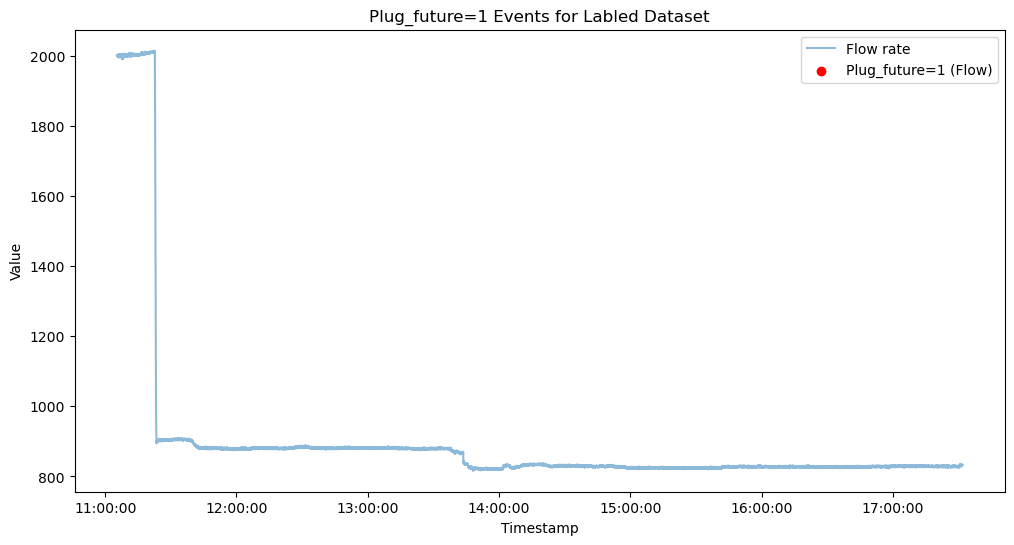

In [79]:
set_no_plug(dataset7)
dataset7 = add_logId_column(dataset7, 7)
dv.visualize_plug_event(dataset7, anomalies=True, plug_column="Plug_future", name="Labled Dataset")

# Dataset 8
Loop block - 15:11:12-15:16:10  - first run
orifice block - 15:19:56-15:24:32 - second run

In [80]:
show_info(dataset8)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']
Duplicate rows: 4
Duplicate index timestamps: 4


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
1900-01-01 14:51:06.330,22.084809,23.496209,22.423823,22.306702,-0.001149,-0.000124,0.037587,1.127421
1900-01-01 14:51:07.330,22.086515,23.472452,22.425135,22.309064,-0.001296,-0.000103,0.037991,1.004836
1900-01-01 14:51:08.330,22.086122,23.481640,22.424741,22.308014,-0.001181,-0.000035,0.038083,0.948259
1900-01-01 14:51:09.330,22.088222,23.485972,22.425135,22.310245,-0.000960,0.000044,0.038221,1.103847
1900-01-01 14:51:10.330,22.084546,23.490697,22.424085,22.312214,-0.001223,0.000075,0.037973,1.094418


In [81]:
# cut out 
# 1500 - 1700 and 2000 - 2200 
dataset8 = cut(dataset8, 1500, 1700)
dataset8 = cut(dataset8, 2000, 2200)

In [82]:
# find first plug
start_time_first_plug = '15:11:12'
end_time_first_plug = '15:16:10'

start_time_second_plug = '15:19:56'
end_time_second_plug = '15:24:32'

dataset8 = add_logId_column(dataset8, 8)

set_plug_at_time(dataset8, start_time_first_plug, end_time_first_plug)
set_plug_at_time(dataset8, start_time_second_plug, end_time_second_plug)
dp.create_future_target(dataset8)

In [83]:
cut_time = dataset8.index[0] + pd.Timedelta(seconds=1500)

first_dataset8 = dataset8[(dataset8.index < cut_time)]
second_dataset8 = dataset8[(dataset8.index > cut_time)]

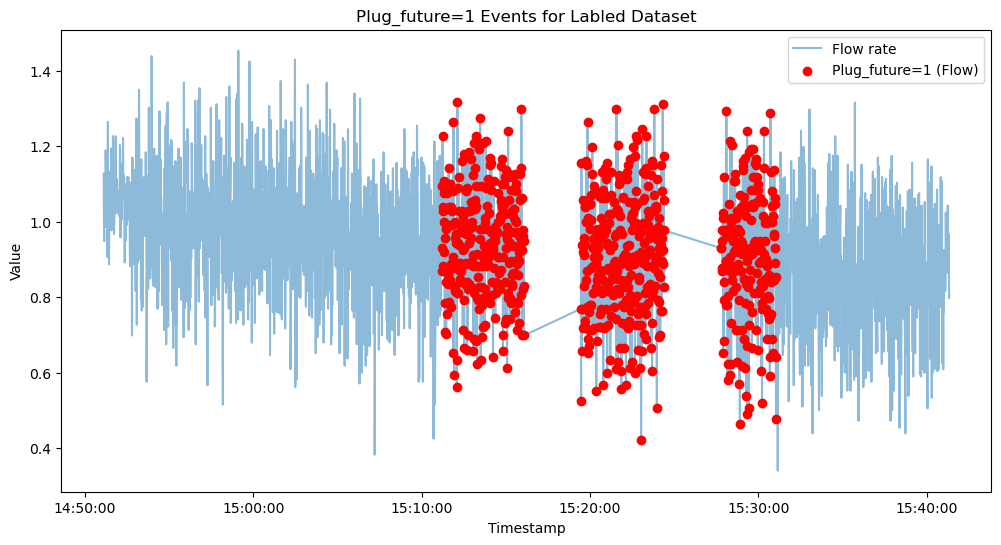

In [84]:
dv.visualize_plug_event(dataset8, anomalies=True, plug_column="Plug_future", name="Labled Dataset")

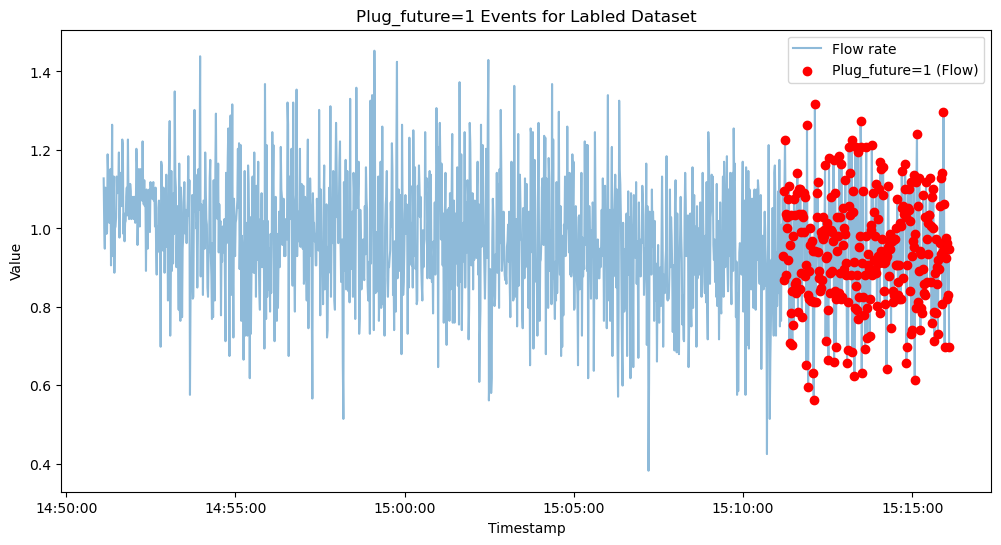

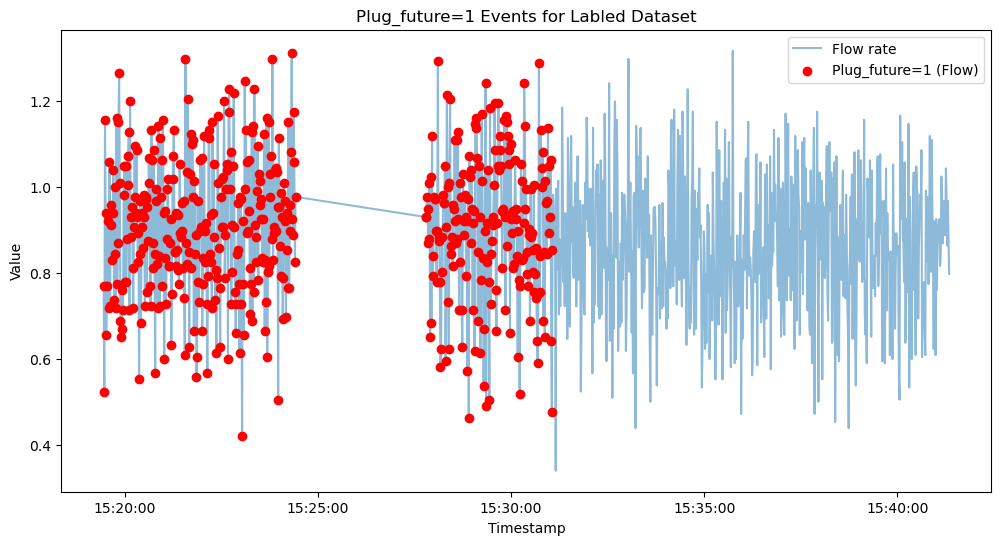

In [85]:
dv.visualize_plug_event(first_dataset8, anomalies=True, plug_column="Plug_future", name="Labled Dataset")
dv.visualize_plug_event(second_dataset8, anomalies=True, plug_column="Plug_future", name="Labled Dataset")

# Dataset 9
13:15:49-13:44:06 - test section block

In [86]:
show_info(dataset9)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']
Duplicate rows: 0
Duplicate index timestamps: 0


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
1900-01-01 12:50:22.552,22.105023,22.784024,22.143948,21.820424,-0.001144,0.001010,0.030614,0.962403
1900-01-01 12:50:23.552,22.103317,22.764467,22.139616,21.815305,-0.001050,0.001136,0.030568,1.070844
1900-01-01 12:50:24.552,22.107123,22.770242,22.134496,21.820030,-0.001286,0.001178,0.030586,1.136851
1900-01-01 12:50:25.552,22.105286,22.778642,22.133052,21.819111,-0.001212,0.001152,0.030779,1.150995
1900-01-01 12:50:26.552,22.104104,22.769192,22.133183,21.818061,-0.001223,0.000873,0.030467,1.188714


In [87]:
set_plug_at_time(dataset9, '13:15:49', '13:44:06')
dataset9 = add_logId_column(dataset9, 9)
dp.create_future_target(dataset9)

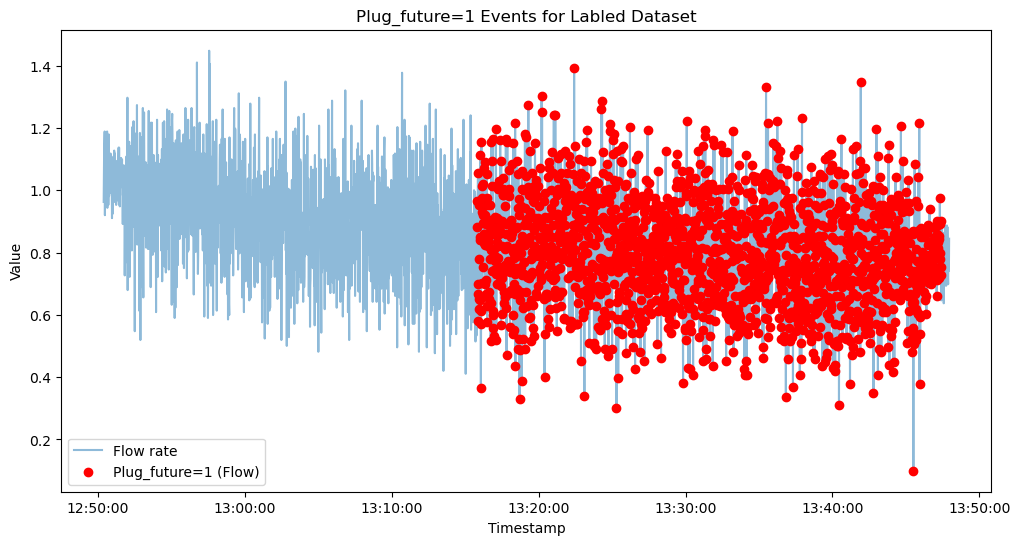

In [88]:
dv.visualize_plug_event(dataset9, anomalies=True, plug_column="Plug_future", name="Labled Dataset")

# Dataset 10
3 runs

13:57:15 - 13:59:21 -> Run 1 - loop blockage

14:01:48 - 14:06:57 -> Run 2 - orifice blockage

14:27:16 - 14:31:41 -> Run 3 - no block

In [89]:
show_info(dataset10)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']
Duplicate rows: 0
Duplicate index timestamps: 0


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
1900-01-01 13:55:39.663,21.999620,-2.009256,24.051350,-2.157328,0.354064,0.366056,0.646015,0.622937
1900-01-01 13:55:40.663,21.992532,-2.007550,24.048330,-2.145516,0.354553,0.366539,0.646474,1.042555
1900-01-01 13:55:41.663,21.996995,-2.005187,24.044261,-2.144203,0.354437,0.365835,0.645950,0.740807
1900-01-01 13:55:42.663,21.989644,-2.004662,24.046624,-2.144203,0.354327,0.365914,0.646400,1.165140
1900-01-01 13:55:43.663,21.976124,-2.009256,24.031921,-2.149060,0.354642,0.365273,0.646134,0.886966


In [90]:
set_plug_at_time(dataset10, '13:57:15', '13:59:21')
set_plug_at_time(dataset10, '14:01:48', '14:06:57')
dataset10 = add_logId_column(dataset10, 10)
dp.create_future_target(dataset10)

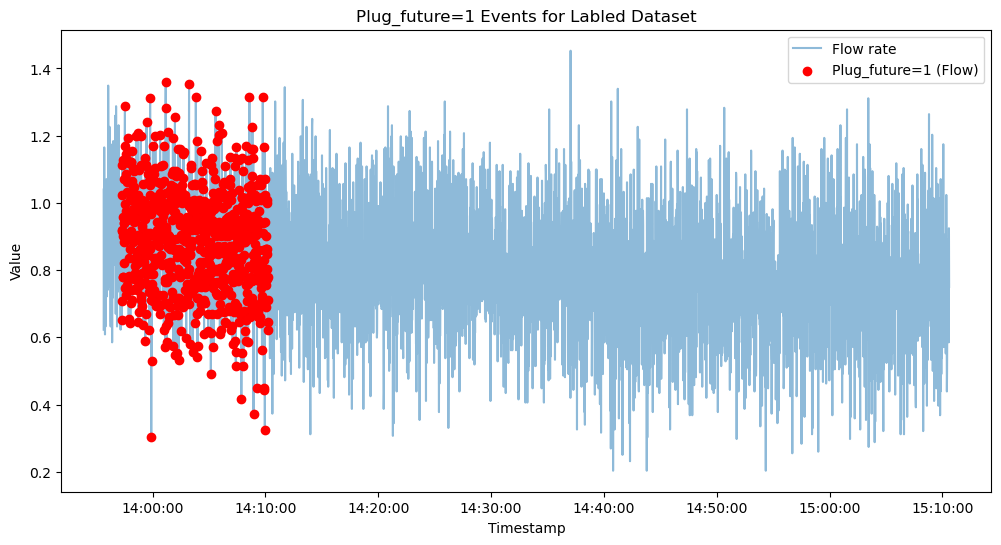

In [91]:
dv.visualize_plug_event(dataset10, anomalies=True, plug_column="Plug_future", name="Labled Dataset")

# Dataset 11

4 runs

Time of runs:

14:33:05 – 15:14:26 -> Run 1

15:20:20 – 15:28:59 -> Run 2 - block

15:33:24 – 15:44:06 -> Run 3 - block

15:49:03 - 16:08:07 -> Run 4 - block

In [92]:
show_info(dataset11)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']
Duplicate rows: 0
Duplicate index timestamps: 0


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
1900-01-01 13:56:49.628,21.208376,-6.971719,23.120621,-7.084154,0.251241,0.261635,0.463390,3.786573
1900-01-01 13:56:50.628,21.208376,-6.971456,23.122066,-7.081135,0.251745,0.262880,0.463335,3.720566
1900-01-01 13:56:51.628,21.223209,-6.960037,23.127054,-7.081267,0.251136,0.261336,0.462848,3.687562
1900-01-01 13:56:52.628,21.197350,-6.963318,23.122197,-7.075360,0.252407,0.262402,0.463518,3.711136
1900-01-01 13:56:53.628,21.198794,-6.957412,23.116027,-7.074573,0.252134,0.262449,0.463188,3.692277


In [93]:
set_plug_at_time(dataset11, '15:20:20', '15:28:59')
set_plug_at_time(dataset11, '15:33:24', '15:44:06')
set_plug_at_time(dataset11, '15:49:03', '16:08:07')
dataset11 = add_logId_column(dataset11, 11)
dp.create_future_target(dataset11)

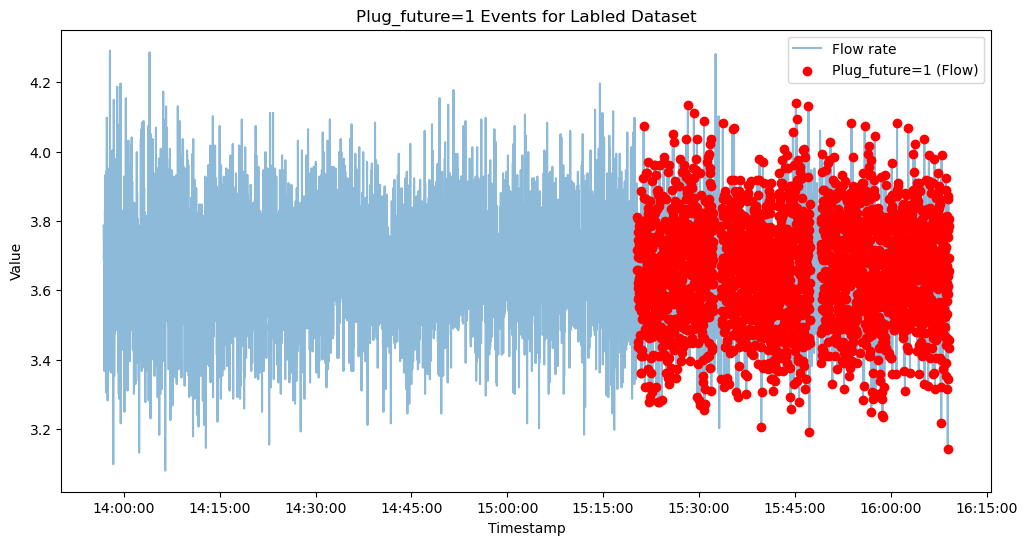

In [94]:
dv.visualize_plug_event(dataset11, anomalies=True, plug_column="Plug_future", name="Labled Dataset")

# Dataset 12
3 runs

Time-codes:

13:53:03 – 15:02:50

15:08:37 – 16:08:03

16:15:39 - 17:03:21 Loop blockage

In [95]:
show_info(dataset12)

Dataset columns: ['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Tank temperature (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Flow rate (Mean)']
Duplicate rows: 0
Duplicate index timestamps: 0


,Temperature TS outlet (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Tank temperature (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Flow rate (Mean)
Time,,,,,,,,
1900-01-01 13:35:02.939,21.251430,-5.328284,22.052975,-5.492760,0.255420,0.269122,0.475168,1.683769
1900-01-01 13:35:03.939,21.254187,-5.318308,22.060589,-5.488297,0.254701,0.268671,0.474984,1.415025
1900-01-01 13:35:04.939,21.252086,-5.320540,22.060195,-5.481210,0.255132,0.268225,0.475122,1.443314
1900-01-01 13:35:05.939,21.230953,-5.324215,22.058620,-5.481341,0.254554,0.268639,0.474617,1.396165
1900-01-01 13:35:06.939,21.234760,-5.317258,22.063477,-5.478191,0.256155,0.269616,0.475710,1.853502


In [96]:
set_plug_at_time(dataset12, '16:15:39', '17:03:21')
dataset12 = add_logId_column(dataset12, 12)
dp.create_future_target(dataset12)

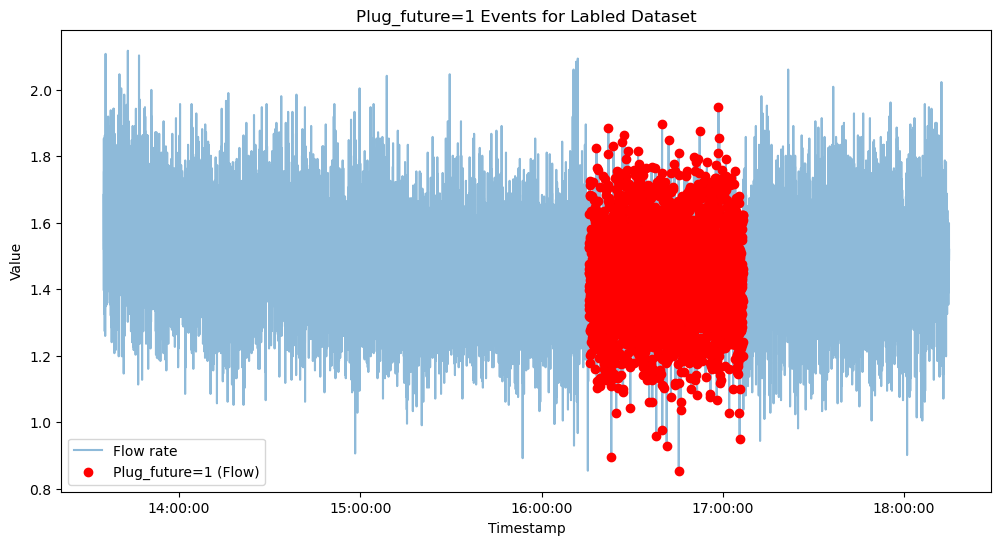

In [97]:
dv.visualize_plug_event(dataset12, anomalies=True, plug_column="Plug_future", name="Labled Dataset")

In [98]:
# print nan values info
datasets = [dataset1, dataset2, dataset3, dataset4, dataset5, dataset6, dataset7, dataset8, dataset9, dataset10, dataset11, dataset12]

if all(df.isna().sum().sum() == 0 for df in datasets):
    print("No NaN values found in any dataset. ✅")
else:
    print("NaN values found in some datasets. ❌")
    print("Number of NaN values in each column:")
    for i, df in enumerate(datasets, start=1):
        print(f"\nDataset {i} NaN values:")
        print(df.isna().sum())

No NaN values found in any dataset. ✅


In [99]:
dfs = [dataset1, dataset2, dataset3, dataset4, dataset5,
       dataset6, dataset7, dataset8, dataset9, dataset10,
       dataset11, dataset12]

for i in range(len(dfs)):
    print("📌 Before removal", dfs[i].columns.tolist())
    
    dfs[i] = dfs[i].loc[:, 
        dfs[i].columns.str.contains("press", case=False, na=False) 
        | dfs[i].columns.isin(['Plug', 'Plug_future', 'LogId', 'Flow rate (Mean)']) #should in theory replace and use non_feature_columns defined in config file
    ]    
    
    print("🏌️‍♀️ AFTER removal", dfs[i].columns.tolist())

# Reassign back to original names
(dataset1, dataset2, dataset3, dataset4, dataset5,
 dataset6, dataset7, dataset8, dataset9, dataset10,
 dataset11, dataset12) = dfs

📌 Before removal ['Flow rate (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Temperature TS outlet (Mean)', 'Tank temperature (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Plug', 'Plug_future', 'LogId']
🏌️‍♀️ AFTER removal ['Flow rate (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Plug', 'Plug_future', 'LogId']
📌 Before removal ['Flow rate (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Temperature TS outlet (Mean)', 'Tank temperature (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Plug', 'Plug_future', 'LogId']
🏌️‍♀️ AFTER removal ['Flow rate (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Plug', 'Plug_future', 'LogId']
📌 Before removal ['TS outlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Differential pressure (Mean)', 'Flow rate (Me

In [101]:
dataset1

,Flow rate (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Plug,Plug_future,LogId
Time,,,,,,,
1900-01-01 09:13:23.564,2006.990755,0.663001,1.006496,1.122522,0,0.0,1
1900-01-01 09:13:23.614,2006.802163,0.666047,1.010171,1.129320,0,0.0,1
1900-01-01 09:13:23.664,2006.990755,0.666782,1.016682,1.137956,0,0.0,1
1900-01-01 09:13:23.714,2005.764905,0.662791,1.010171,1.127850,0,0.0,1
1900-01-01 09:13:23.764,2005.576313,0.663421,1.014057,1.130607,0,0.0,1
...,...,...,...,...,...,...,...
1900-01-01 13:50:49.314,1.877076,0.056164,0.056696,0.091709,1,1.0,1
1900-01-01 13:50:49.364,2.442853,0.055849,0.056801,0.091709,1,1.0,1
1900-01-01 13:50:49.414,1.594187,0.055744,0.056591,0.091709,1,1.0,1


# Save data to new csv files
Save data to new csv files with the lables to be used later in model traning. 

In [100]:
save_labeled_data(dataset1, "data1")
save_labeled_data(dataset2, "data2")
save_labeled_data(dataset3, "data3")
save_labeled_data(dataset4, "data4")
save_labeled_data(dataset5, "data5")
save_labeled_data(dataset6, "data6")
save_labeled_data(dataset7, "data7")
save_labeled_data(dataset8, "data8")
save_labeled_data(dataset9, "data9")
save_labeled_data(dataset10, "data10")
save_labeled_data(dataset11, "data11")
save_labeled_data(dataset12, "data12")

Labeled data saved to /Users/karolinagil/Documents/Master/data/labeled/labeled_data1.csv
Labeled data saved to /Users/karolinagil/Documents/Master/data/labeled/labeled_data2.csv
Labeled data saved to /Users/karolinagil/Documents/Master/data/labeled/labeled_data3.csv
Labeled data saved to /Users/karolinagil/Documents/Master/data/labeled/labeled_data4.csv
Labeled data saved to /Users/karolinagil/Documents/Master/data/labeled/labeled_data5.csv
Labeled data saved to /Users/karolinagil/Documents/Master/data/labeled/labeled_data6.csv
Labeled data saved to /Users/karolinagil/Documents/Master/data/labeled/labeled_data7.csv
Labeled data saved to /Users/karolinagil/Documents/Master/data/labeled/labeled_data8.csv
Labeled data saved to /Users/karolinagil/Documents/Master/data/labeled/labeled_data9.csv
Labeled data saved to /Users/karolinagil/Documents/Master/data/labeled/labeled_data10.csv
Labeled data saved to /Users/karolinagil/Documents/Master/data/labeled/labeled_data11.csv
Labeled data saved 